# Feature Engineering (Distributed Spark)

This notebook builds a dense 10-minute demand table by ZoneID and creates time-series features.

Outputs:
- HDFS: /user/data/feature_engineering/demand_prediction_dense_10m
- HDFS: /user/data/feature_engineering/demand_prediction_features
- Local artifacts: /workspace/code/hybrid_regression_holt_winters/artifacts/feature_engineering
- Local results: /workspace/code/hybrid_regression_holt_winters/results/feature_engineering

Time window behavior:
- Auto-detects available min/max timestamp from input data by default.
- Optionally set START_TS and END_TS to limit the window.

In [8]:
import json
import os
import urllib.request

import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import SparkSession, functions as F, Window

spark = (
    SparkSession.builder
    .appName("DemandPredictionFeatureEngineering")
    .master("spark://master:7077")
    .config("spark.driver.memory", "2g")
    .config("spark.executor.memory", "2g")
    .config("spark.eventLog.enabled", "true")
    .config("spark.eventLog.dir", "hdfs://master:9000/spark-logs")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

def cluster_util(stage_name):
    print(f"\n===== CLUSTER UTILIZATION: {stage_name} =====")
    print("Spark master:", spark.sparkContext.master)
    try:
        payload = json.load(urllib.request.urlopen("http://master:8080/json/"))
        workers = payload.get("workers", [])
        print("alive workers:", payload.get("aliveworkers"))
        print("active apps :", len(payload.get("activeapps", [])))
        for w in workers:
            print("worker", w.get("id"), "cores", f"{w.get('coresused', 0)}/{w.get('cores', 0)}", "memory", f"{w.get('memoryused', 0)}/{w.get('memory', 0)}")
    except Exception as e:
        print("Could not query Spark Master JSON:", e)

cluster_util("session_started")


===== CLUSTER UTILIZATION: session_started =====
Spark master: spark://master:7077
alive workers: 3
active apps : 1
worker worker-20260404042505-172.18.0.3-7078 cores 2/2 memory 2048/2048
worker worker-20260404042505-172.18.0.4-7078 cores 2/2 memory 2048/2048
worker worker-20260404042557-172.18.0.2-7078 cores 2/2 memory 2048/2048


## Data Preprocessing (In-Memory, No Disk Write)

This section cleans raw trips before feature engineering and prints a cleaning summary directly in the notebook.

Cleaning rules in this notebook:
- Parse pickup timestamp from supported columns
- Keep non-null ZoneID and ZoneID > 0
- Detect timestamp outliers using IQR (Q1/Q3, Tukey fences), no fixed year hardcode

In [10]:
RAW_PATH = "/user/data/raw/*.parquet"
OUT_DENSE = "/user/data/feature_engineering/demand_prediction_dense_10m"
OUT_FEATURES = "/user/data/feature_engineering/demand_prediction_features"

LOCAL_BASE = "/workspace/code/hybrid_regression_holt_winters"
LOCAL_RESULTS_DIR = f"{LOCAL_BASE}/results/feature_engineering"
LOCAL_ARTIFACTS_DIR = f"{LOCAL_BASE}/artifacts/feature_engineering"
os.makedirs(LOCAL_RESULTS_DIR, exist_ok=True)
os.makedirs(LOCAL_ARTIFACTS_DIR, exist_ok=True)

# Optional manual override; keep None to auto-detect from cleaned data.
START_TS = None
END_TS = None

ZONE_COL = "PULocationID"
BIN_COL = "pickup_bin_10m"
TARGET_COL = "pickup_demand"
PICKUP_COL_CANDIDATES = ["tpep_pickup_datetime", "lpep_pickup_datetime", "pickup_datetime"]

raw_df = spark.read.parquet(RAW_PATH)
pickup_col = next((c for c in PICKUP_COL_CANDIDATES if c in raw_df.columns), None)
if pickup_col is None:
    raise ValueError(f"Cannot find pickup timestamp column. Tried: {PICKUP_COL_CANDIDATES}")
if ZONE_COL not in raw_df.columns:
    raise ValueError(f"Missing column: {ZONE_COL}")

typed_df = raw_df.select(
    F.to_timestamp(F.col(pickup_col)).alias("pickup_ts"),
    F.col(ZONE_COL).cast("int").alias(ZONE_COL),
)

raw_rows = raw_df.count()
null_pickup_rows = typed_df.where(F.col("pickup_ts").isNull()).count()
null_zone_rows = typed_df.where(F.col(ZONE_COL).isNull()).count()
nonpositive_zone_rows = typed_df.where(F.col(ZONE_COL) <= 0).count()

valid_for_iqr = typed_df.where(F.col("pickup_ts").isNotNull())
iqr_bounds = valid_for_iqr.agg(
    F.expr("percentile_approx(unix_timestamp(pickup_ts), 0.25)").alias("q1_epoch"),
    F.expr("percentile_approx(unix_timestamp(pickup_ts), 0.75)").alias("q3_epoch")
).first()

if iqr_bounds["q1_epoch"] is None or iqr_bounds["q3_epoch"] is None:
    raise ValueError("Cannot compute IQR bounds for pickup timestamp.")

q1_epoch = int(iqr_bounds["q1_epoch"])
q3_epoch = int(iqr_bounds["q3_epoch"])
iqr_epoch = max(q3_epoch - q1_epoch, 1)
lower_epoch = q1_epoch - int(1.5 * iqr_epoch)
upper_epoch = q3_epoch + int(1.5 * iqr_epoch)

lower_ts = pd.to_datetime(lower_epoch, unit="s")
upper_ts = pd.to_datetime(upper_epoch, unit="s")

time_outlier_rows_iqr = typed_df.where(
    F.col("pickup_ts").isNotNull() & (
        (F.unix_timestamp("pickup_ts") < F.lit(lower_epoch)) |
        (F.unix_timestamp("pickup_ts") > F.lit(upper_epoch))
    )
).count()

base_trips = (
    typed_df
    .where(F.col("pickup_ts").isNotNull())
    .where(F.col(ZONE_COL).isNotNull())
    .where(F.col(ZONE_COL) > 0)
    .where(F.unix_timestamp("pickup_ts").between(lower_epoch, upper_epoch))
)

available_bounds = base_trips.agg(
    F.min("pickup_ts").alias("min_ts"),
    F.max("pickup_ts").alias("max_ts")
).first()
clean_rows = base_trips.count()

if clean_rows == 0 or available_bounds["min_ts"] is None or available_bounds["max_ts"] is None:
    raise ValueError(
        "No valid rows remain after preprocessing. "
        "Check timestamp parsing, ZoneID quality, and IQR filtering bounds."
    )

print("Using pickup column:", pickup_col)
print("IQR timestamp bounds:", lower_ts, "->", upper_ts)
print("Cleaned available range:", available_bounds["min_ts"], "->", available_bounds["max_ts"])

cleaning_report = pd.DataFrame(
    [
        {"metric": "raw_rows", "count": int(raw_rows)},
        {"metric": "removed_null_pickup_ts", "count": int(null_pickup_rows)},
        {"metric": "removed_null_zone", "count": int(null_zone_rows)},
        {"metric": "removed_nonpositive_zone", "count": int(nonpositive_zone_rows)},
        {"metric": "removed_time_outliers_iqr", "count": int(time_outlier_rows_iqr)},
        {"metric": "rows_after_cleaning", "count": int(clean_rows)},
    ]
)
display(cleaning_report)
cluster_util("after_preprocessing")

Using pickup column: tpep_pickup_datetime
IQR timestamp bounds: 2025-09-02 14:47:27 -> 2025-12-28 21:38:02
Cleaned available range: 2025-09-30 22:54:51 -> 2025-11-30 23:59:59


,metric,count
0,raw_rows,8610143
1,removed_null_pickup_ts,0
2,removed_null_zone,0
3,removed_nonpositive_zone,0
4,removed_time_outliers_iqr,3
5,rows_after_cleaning,8610140



===== CLUSTER UTILIZATION: after_preprocessing =====
Spark master: spark://master:7077
alive workers: 3
active apps : 1
worker worker-20260404042505-172.18.0.3-7078 cores 2/2 memory 2048/2048
worker worker-20260404042505-172.18.0.4-7078 cores 2/2 memory 2048/2048
worker worker-20260404042557-172.18.0.2-7078 cores 2/2 memory 2048/2048


In [11]:
effective_start = START_TS if START_TS is not None else available_bounds["min_ts"]
effective_end = END_TS if END_TS is not None else available_bounds["max_ts"]

window_cond = F.col("pickup_ts") >= F.lit(effective_start)
if END_TS is not None:
    window_cond = window_cond & (F.col("pickup_ts") < F.lit(effective_end))
else:
    window_cond = window_cond & (F.col("pickup_ts") <= F.lit(effective_end))

trips = base_trips.where(window_cond)
trip_rows = trips.count()
if trip_rows == 0:
    raise ValueError(
        f"No rows in requested period [{effective_start}, {effective_end}]. "
        f"Available cleaned range is [{available_bounds['min_ts']}, {available_bounds['max_ts']}]."
    )

print("Effective window:", effective_start, "->", effective_end)
print("Trips used after preprocessing:", trip_rows)
cluster_util("after_raw_filter")

Effective window: 2025-09-30 22:54:51 -> 2025-11-30 23:59:59
Trips used after preprocessing: 8610140

===== CLUSTER UTILIZATION: after_raw_filter =====
Spark master: spark://master:7077
alive workers: 3
active apps : 1
worker worker-20260404042505-172.18.0.3-7078 cores 2/2 memory 2048/2048
worker worker-20260404042505-172.18.0.4-7078 cores 2/2 memory 2048/2048
worker worker-20260404042557-172.18.0.2-7078 cores 2/2 memory 2048/2048


In [12]:
demand_10m = (
    trips
    .withColumn(BIN_COL, F.to_timestamp(F.from_unixtime(F.floor(F.unix_timestamp("pickup_ts") / 600) * 600)))
    .groupBy(ZONE_COL, BIN_COL)
    .agg(F.count(F.lit(1)).cast("double").alias(TARGET_COL))
)

zone_dim = demand_10m.select(ZONE_COL).distinct()
time_bounds = demand_10m.agg(F.min(BIN_COL).alias("min_ts"), F.max(BIN_COL).alias("max_ts")).first()

if time_bounds["min_ts"] is None or time_bounds["max_ts"] is None:
    raise ValueError("No demand rows found in selected period.")

time_dim = (
    spark.range(1)
    .select(F.sequence(F.lit(time_bounds["min_ts"]), F.lit(time_bounds["max_ts"]), F.expr("interval 10 minutes")).alias("bins"))
    .select(F.explode(F.col("bins")).alias(BIN_COL))
)

dense_df = (
    zone_dim.crossJoin(time_dim)
    .join(demand_10m, on=[ZONE_COL, BIN_COL], how="left")
    .fillna({TARGET_COL: 0.0})
    .repartition(64, ZONE_COL)
    .cache()
)

dense_rows = dense_df.count()
print("Dense rows:", dense_rows)
cluster_util("after_dense_table")

Dense rows: 2303242

===== CLUSTER UTILIZATION: after_dense_table =====
Spark master: spark://master:7077
alive workers: 3
active apps : 1
worker worker-20260404042505-172.18.0.3-7078 cores 2/2 memory 2048/2048
worker worker-20260404042505-172.18.0.4-7078 cores 2/2 memory 2048/2048
worker worker-20260404042557-172.18.0.2-7078 cores 2/2 memory 2048/2048


In [13]:
w = Window.partitionBy(ZONE_COL).orderBy(BIN_COL)
w_hist_6 = w.rowsBetween(-6, -1)
w_hist_18 = w.rowsBetween(-18, -1)
w_count = Window.partitionBy(ZONE_COL)

features_df = (
    dense_df
    .withColumn("hour", F.hour(BIN_COL).cast("double"))
    .withColumn("dow", F.dayofweek(BIN_COL).cast("double"))
    .withColumn("month", F.month(BIN_COL).cast("double"))
    .withColumn("is_weekend", F.when(F.dayofweek(BIN_COL).isin([1, 7]), F.lit(1.0)).otherwise(F.lit(0.0)))
    .withColumn("lag_1", F.lag(TARGET_COL, 1).over(w).cast("double"))
    .withColumn("lag_2", F.lag(TARGET_COL, 2).over(w).cast("double"))
    .withColumn("lag_3", F.lag(TARGET_COL, 3).over(w).cast("double"))
    .withColumn("lag_6", F.lag(TARGET_COL, 6).over(w).cast("double"))
    .withColumn("lag_12", F.lag(TARGET_COL, 12).over(w).cast("double"))
    .withColumn("lag_144", F.lag(TARGET_COL, 144).over(w).cast("double"))
    .withColumn("lag_1008", F.lag(TARGET_COL, 1008).over(w).cast("double"))
    .withColumn("roll_mean_6", F.avg(TARGET_COL).over(w_hist_6).cast("double"))
    .withColumn("roll_mean_18", F.avg(TARGET_COL).over(w_hist_18).cast("double"))
    .withColumn("roll_std_18", F.stddev_pop(TARGET_COL).over(w_hist_18).cast("double"))
    .dropna()
    .withColumn("rn", F.row_number().over(w))
    .withColumn("n_zone", F.count(F.lit(1)).over(w_count))
    .withColumn("train_cut", F.floor(F.col("n_zone") * F.lit(0.7)))
    .withColumn("split", F.when(F.col("rn") <= F.col("train_cut"), F.lit("train")).otherwise(F.lit("test")))
    .cache()
)

feature_rows = features_df.count()
print("Feature rows:", feature_rows)
features_df.groupBy("split").count().show()
cluster_util("after_feature_engineering")

Feature rows: 2039146
+-----+-------+
|split|  count|
+-----+-------+
|train|1427376|
| test| 611770|
+-----+-------+


===== CLUSTER UTILIZATION: after_feature_engineering =====
Spark master: spark://master:7077
alive workers: 3
active apps : 1
worker worker-20260404042505-172.18.0.3-7078 cores 2/2 memory 2048/2048
worker worker-20260404042505-172.18.0.4-7078 cores 2/2 memory 2048/2048
worker worker-20260404042557-172.18.0.2-7078 cores 2/2 memory 2048/2048


In [14]:
dense_df.write.mode("overwrite").parquet(OUT_DENSE)
features_df.write.mode("overwrite").parquet(OUT_FEATURES)

run_meta = {
    "raw_path": RAW_PATH,
    "pickup_column": pickup_col,
    "effective_start": str(effective_start),
    "effective_end": str(effective_end),
    "dense_rows": int(dense_rows),
    "feature_rows": int(feature_rows),
    "cleaning_summary": {
        "raw_rows": int(raw_rows),
        "removed_null_pickup_ts": int(null_pickup_rows),
        "removed_null_zone": int(null_zone_rows),
        "removed_nonpositive_zone": int(nonpositive_zone_rows),
        "removed_time_outliers_iqr": int(time_outlier_rows_iqr),
        "iqr_lower_ts": str(lower_ts),
        "iqr_upper_ts": str(upper_ts),
        "rows_after_cleaning": int(clean_rows),
    },
    "hdfs_outputs": {
        "dense": OUT_DENSE,
        "features": OUT_FEATURES,
    },
}

with open(f"{LOCAL_RESULTS_DIR}/run_metadata.json", "w", encoding="utf-8") as f:
    json.dump(run_meta, f, indent=2)

print("Saved HDFS outputs:")
print("-", OUT_DENSE)
print("-", OUT_FEATURES)
print("Saved local metadata:")
print("-", f"{LOCAL_RESULTS_DIR}/run_metadata.json")
cluster_util("after_feature_write")

Saved HDFS outputs:
- /user/data/feature_engineering/demand_prediction_dense_10m
- /user/data/feature_engineering/demand_prediction_features
Saved local metadata:
- /workspace/code/hybrid_regression_holt_winters/results/feature_engineering/run_metadata.json

===== CLUSTER UTILIZATION: after_feature_write =====
Spark master: spark://master:7077
alive workers: 3
active apps : 1
worker worker-20260404042505-172.18.0.3-7078 cores 2/2 memory 2048/2048
worker worker-20260404042505-172.18.0.4-7078 cores 2/2 memory 2048/2048
worker worker-20260404042557-172.18.0.2-7078 cores 2/2 memory 2048/2048


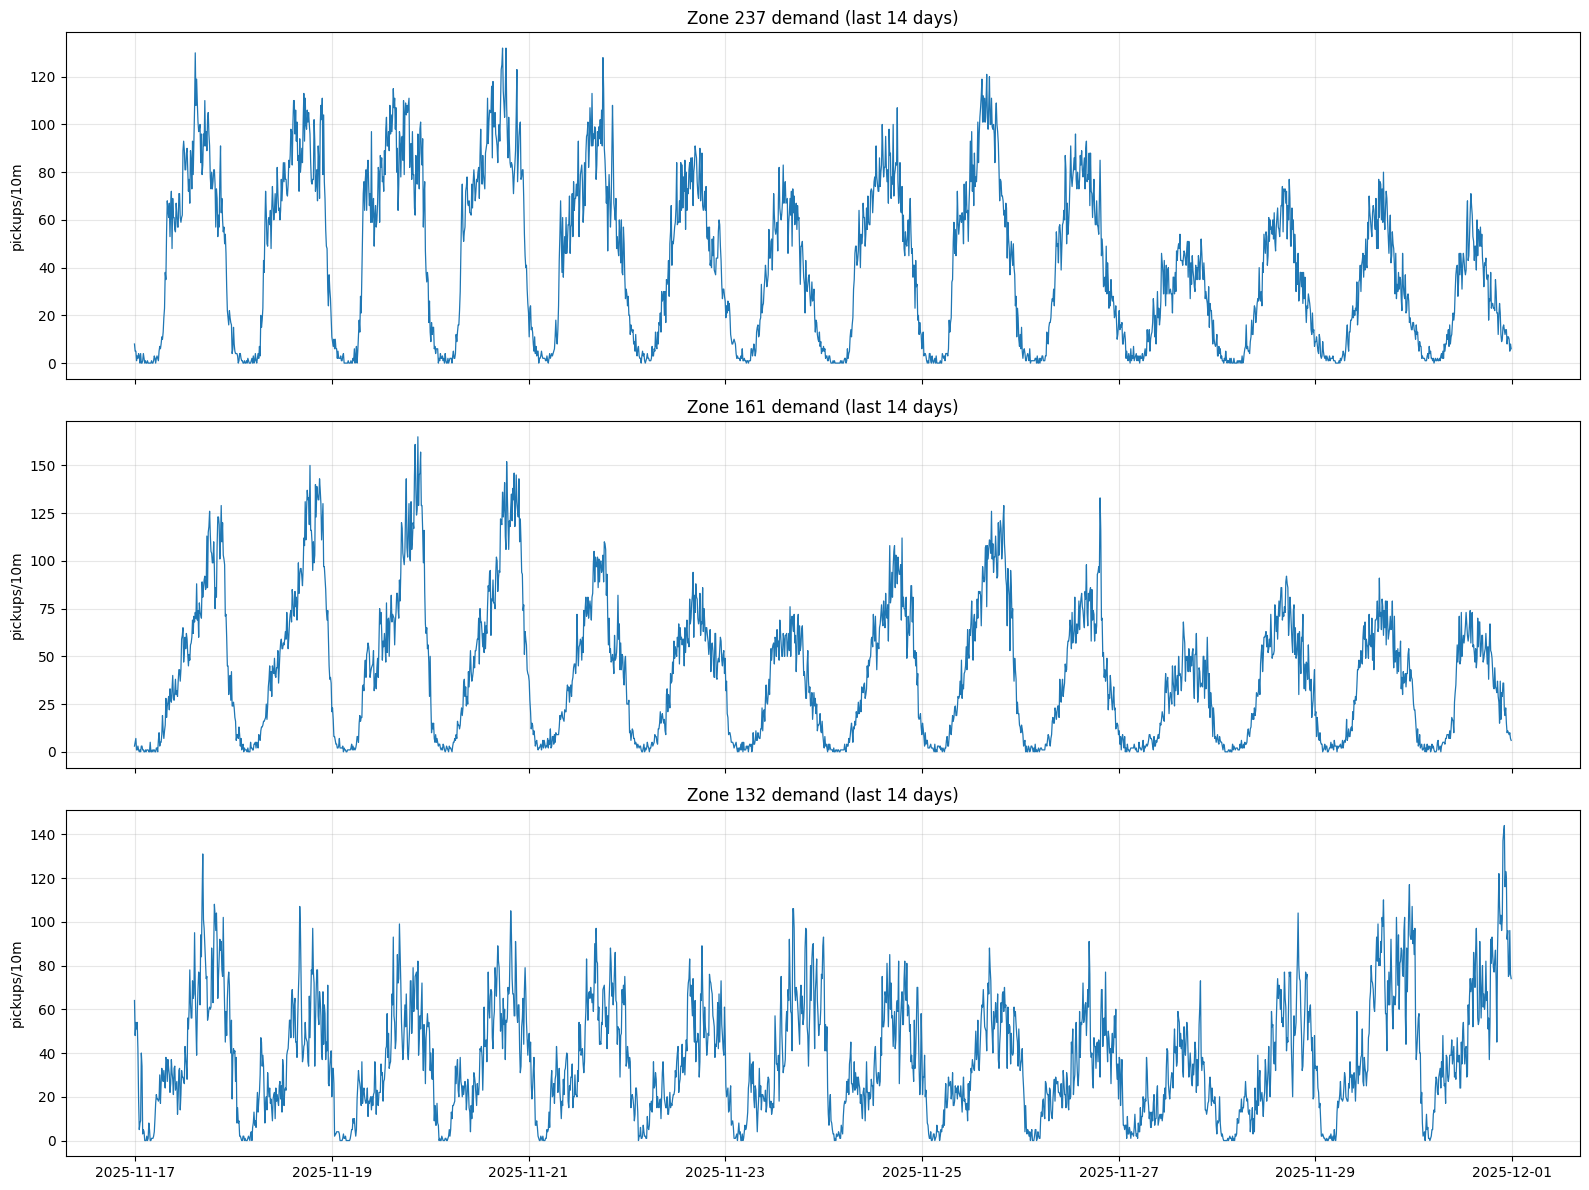

Saved local preview: /workspace/code/hybrid_regression_holt_winters/results/feature_engineering/top_zone_14d_preview.csv
Saved local plot   : /workspace/code/hybrid_regression_holt_winters/artifacts/feature_engineering/top_zone_14d_plot.png


In [15]:
zone_rank = (
    dense_df.groupBy(ZONE_COL).agg(F.sum(TARGET_COL).alias("total"))
    .orderBy(F.col("total").desc())
    .limit(3)
)
top_zones = [r[ZONE_COL] for r in zone_rank.collect()]

max_bin = dense_df.agg(F.max(BIN_COL).alias("max_bin")).first()["max_bin"]
plot_start = pd.Timestamp(max_bin) - pd.Timedelta(days=14)

plot_df = (
    dense_df.where(F.col(ZONE_COL).isin(top_zones))
    .where(F.col(BIN_COL) >= F.to_timestamp(F.lit(str(plot_start))))
    .orderBy(ZONE_COL, BIN_COL)
    .toPandas()
)

preview_csv_path = f"{LOCAL_RESULTS_DIR}/top_zone_14d_preview.csv"
plot_png_path = f"{LOCAL_ARTIFACTS_DIR}/top_zone_14d_plot.png"

if len(plot_df) > 0:
    plot_df.to_csv(preview_csv_path, index=False)

    fig, axes = plt.subplots(len(top_zones), 1, figsize=(16, 4 * len(top_zones)), sharex=True)
    if len(top_zones) == 1:
        axes = [axes]
    for ax, z in zip(axes, top_zones):
        tmp = plot_df[plot_df[ZONE_COL] == z]
        ax.plot(tmp[BIN_COL], tmp[TARGET_COL], linewidth=0.9)
        ax.set_title(f"Zone {z} demand (last 14 days)")
        ax.set_ylabel("pickups/10m")
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(plot_png_path, dpi=130, bbox_inches="tight")
    plt.show()

    print("Saved local preview:", preview_csv_path)
    print("Saved local plot   :", plot_png_path)
else:
    print("No data for plotting.")

In [16]:
# Release Spark cluster resources for subsequent notebooks (e.g., training).
spark.catalog.clearCache()
spark.stop()
print("Feature engineering Spark session stopped.")

Feature engineering Spark session stopped.
